# combine master files

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module version_information is installed


### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [2]:
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

This notebook was generated at 2023-01-28 20:08:49 (대한민국 표준시 = GMT+0900) 
0 Python     3.9.7 64bit [MSC v.1916 64 bit (AMD64)]
1 IPython    7.31.1
2 OS         Windows 10 10.0.22621 SP0
3 numpy      1.21.5
4 pandas     1.4.1
5 matplotlib 3.5.1
6 scipy      1.7.3
7 astropy    5.0
8 photutils  1.5.0
9 ccdproc    2.3.1
10 version_information 1.0.4


### import modules

In [3]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip
from ccdproc import combine, ccd_process, CCDData

import ysfitsutilpy as yfu
import ysphotutilpy as ypu
import ysvisutilpy as yvu

import astro_utilities
import Python_utilities

plt.rcParams.update({'figure.max_open_warning': 0})

c:\users\kiehyun\downloads\ysphotutilpy\ysphotutilpy\seputil.py:112: UserWarning: Package sep is not installed. Some functions will not work.
  warn("Package sep is not installed. Some functions will not work.")


In [4]:
#%%
BASEDIR = astro_utilities.base_dir

BASEDIRs = sorted(Python_utilities.getFullnameListOfsubDir(BASEDIR))
print ("BASEDIRs: {}".format(BASEDIRs))
print ("len(BASEDIRs): {}".format(len(BASEDIRs)))


BASEDIR = Path(BASEDIRs[0])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / astro_utilities.master_dir

if not MASTERDIR.exists():
    os.makedirs("{}".format(str(MASTERDIR)))
    print("{} is created...".format(str(MASTERDIR)))

BASEDIRs: ['R:\\CCD_obs\\RiLA600_2022\\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\ESO606-10_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M103_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M15_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M27_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M2_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M34_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bi

In [5]:

summary = yfu.make_summary(BASEDIR/"*.fit*")
#print(summary)
print("len(summary):", len(summary))
print("summary:", summary)
#print(summary["file"][0])

All 46 keywords (guessed from R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\-_Bias_-_2022-10-20-12-36-37_001sec_RiLA600_STX-16803_-30C_1bin.fit) will be loaded.


c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key EXTEND not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\-_Flat_V_2022-10-12-09-04-29_000sec_RiLA600_STX-16803_-19C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key DATE-LOC not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\-_Flat_V_2022-10-12-09-04-29_000sec_RiLA600_STX-16803_-19C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key FOCRATIO not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\-_Flat_V_2022-10-12-09-04-29_000sec_RiLA600_STX-16803_-19C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloa

len(summary): 68
summary:                                                  file  filesize  SIMPLE  \
0   R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
1   R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
2   R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
3   R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
4   R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
..                                                ...       ...     ...   
63  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
64  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
65  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
66  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   
67  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33560640    True   

    BITPIX  NAXIS  NAXIS1  NAXIS2 EXTEND    BZERO IMAGETYP  ...   OBJCTDE

c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key OPTIC not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key CCDNAME not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key GAIN not found for R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))


### BIAS

In [6]:
bias_fits = summary.loc[summary["IMAGETYP"] == "BIAS"].copy()
bias_fits.reset_index(inplace=True)
bias_fits = bias_fits["file"]
print(type(bias_fits))
print(len(bias_fits))
print(bias_fits)


<class 'pandas.core.series.Series'>
20
0     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
1     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
2     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
3     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
4     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
5     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
6     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
7     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
8     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
9     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
10    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
11    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
12    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
13    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
14    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
15    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
16    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
17    R:\

In [7]:
if (MASTERDIR/'master_bias.fits').exists():
    print(f"{(MASTERDIR/'master_bias.fits')} is already exist...")
else:
    method = "median"
    bias = combine(bias_fits.tolist(),       # ccdproc does not accept numpy.ndarray, but only python list.
                        method = method,         # default is average so I specified median.
                        unit='adu')              # unit is required: it's ADU in our case.

    bias.data = np.array(bias.data, dtype=np.float32)

    print('type(bias.data)', type(bias.data))
    print('bias.data.shape', bias.data.shape)
    print('bias', bias)
    bias.write(f"{str(MASTERDIR/'master_bias.fits')}", overwrite =True)
    print(f"{(MASTERDIR/'master_bias.fits')} is created...")


INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]


type(bias.data) <class 'numpy.ndarray'>
bias.data.shape (4096, 4096)
bias [[1088.5 1073.  1077.  ... 1067.  1061.  1083. ]
 [1086.  1083.  1076.  ... 1061.5 1066.  1089.5]
 [1091.5 1089.  1079.  ... 1060.  1067.  1084.5]
 ...
 [1092.  1081.5 1076.  ... 1085.  1085.5 1123.5]
 [1085.  1085.5 1079.  ... 1082.  1090.  1107.5]
 [1087.  1081.5 1077.  ... 1081.5 1090.  1118. ]] adu
R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\master_files_ys\master_bias.fits is created...


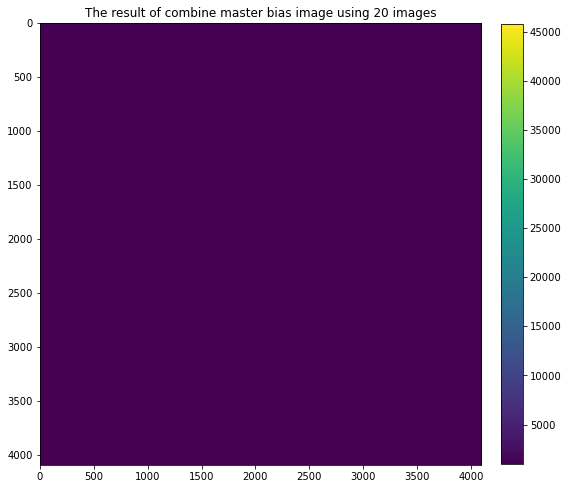

In [8]:
from astropy.io import fits
hdul_bias = fits.open(f"{str(MASTERDIR/'master_bias.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = axs.imshow(hdul_bias[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master bias image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

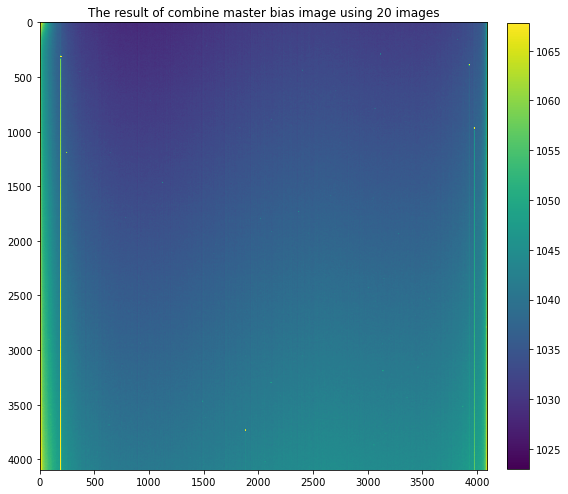

In [9]:
from astropy.io import fits
hdul_bias = fits.open(f"{str(MASTERDIR/'master_bias.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul_bias[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master bias image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

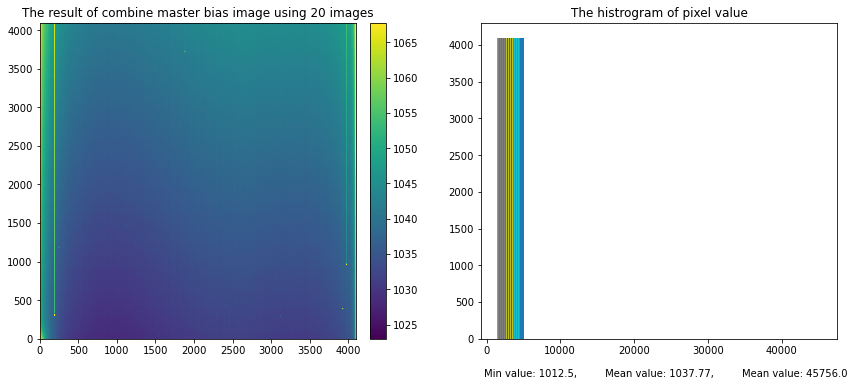

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul_bias[0].data)
im2 = axs[1].hist(hdul_bias[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
        Mean value: {hdul_bias[0].data.mean():.02f}, \
        Mean value: {hdul_bias[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

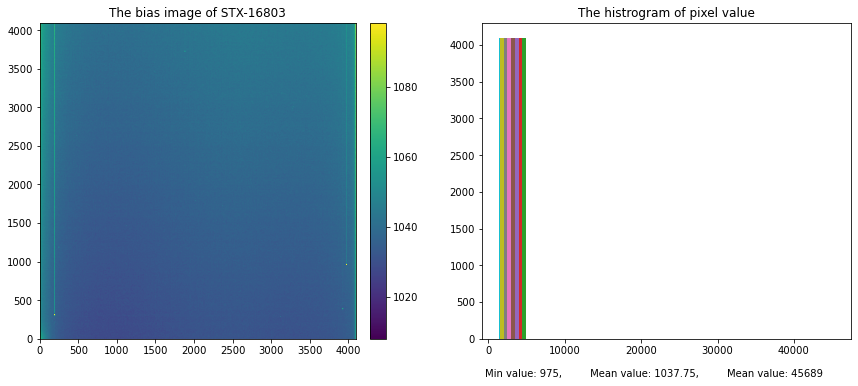

In [11]:
hdul = fits.open(bias_fits[12])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The bias image of STX-16803')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul[0].data.min()}, \
        Mean value: {hdul[0].data.mean():.02f}, \
        Mean value: {hdul[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

### DARK

In [12]:
dark_fits = summary.loc[summary["IMAGETYP"] == "DARK"].copy()
dark_fits.reset_index(inplace=True)
dark_fits = dark_fits["file"]
print(type(dark_fits))
print(len(dark_fits))
print(dark_fits)

<class 'pandas.core.series.Series'>
20
0     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
1     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
2     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
3     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
4     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
5     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
6     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
7     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
8     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
9     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
10    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
11    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
12    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
13    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
14    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
15    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
16    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
17    R:\

In [13]:
if (MASTERDIR/'master_dark0.fits').exists():
    print(f"{(MASTERDIR/'master_dark0.fits')} is already exist...")
else:
    method = "median"
    dark0 = combine(dark_fits.tolist(),       # ccdproc does not accept numpy.ndarray, but only python list.
                        method = method,         # default is average so I specified median.
                        unit='adu')              # unit is required: it's ADU in our case.

    dark0.data = np.array(dark0.data, dtype=np.float32)
    print('type(dark0.data)', type(dark0.data))
    print('dark0.data.shape', dark0.data.shape)
    print('dark0', dark0)
    dark0.write(f"{str(MASTERDIR/'master_dark0.fits')}", overwrite =True)
    print(f"{(MASTERDIR/'master_dark0.fits')} is created...")


INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]


type(dark0.data) <class 'numpy.ndarray'>
dark0.data.shape (4096, 4096)
dark0 [[1081.5 1081.  1073.5 ... 1069.  1066.  1088.5]
 [1079.  1073.  1072.  ... 1067.  1066.  1089. ]
 [1186.5 1078.  1069.5 ... 1059.5 1065.5 1085. ]
 ...
 [1088.  1086.5 1085.  ... 1083.  1086.5 1116. ]
 [1093.  1081.  1078.  ... 1085.5 1088.5 1129. ]
 [1091.5 1081.  1082.  ... 1087.  1091.5 1118.5]] adu
R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\master_files_ys\master_dark0.fits is created...


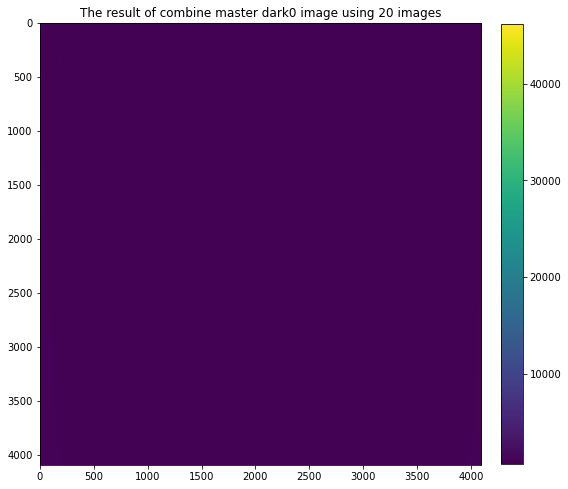

In [14]:
from astropy.io import fits
hdul_dark0 = fits.open(f"{str(MASTERDIR/'master_dark0.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = axs.imshow(hdul_dark0[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master dark0 image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

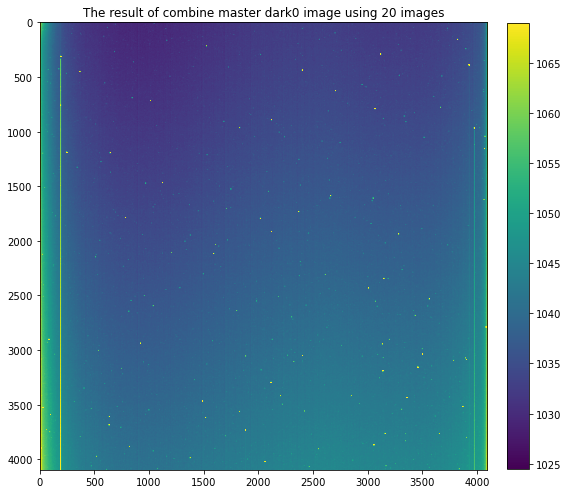

In [15]:
from astropy.io import fits
hdul_dark0 = fits.open(f"{str(MASTERDIR/'master_dark0.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul_dark0[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master dark0 image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)

plt.tight_layout()

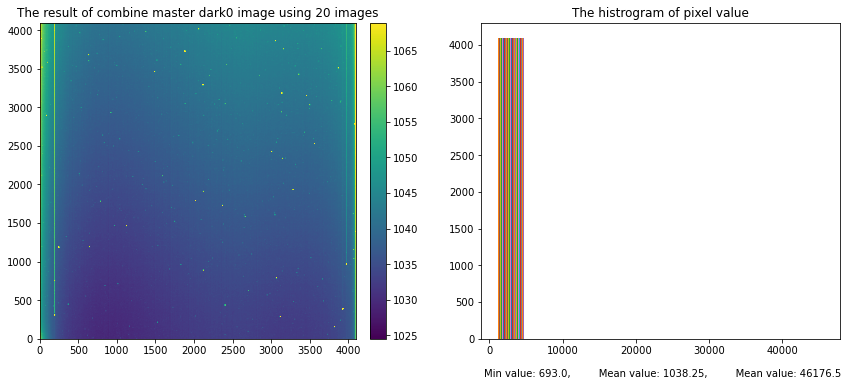

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul_dark0[0].data)
im2 = axs[1].hist(hdul_dark0[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The result of combine master dark0 image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul_dark0[0].data.min()}, \
        Mean value: {hdul_dark0[0].data.mean():.02f}, \
        Mean value: {hdul_dark0[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

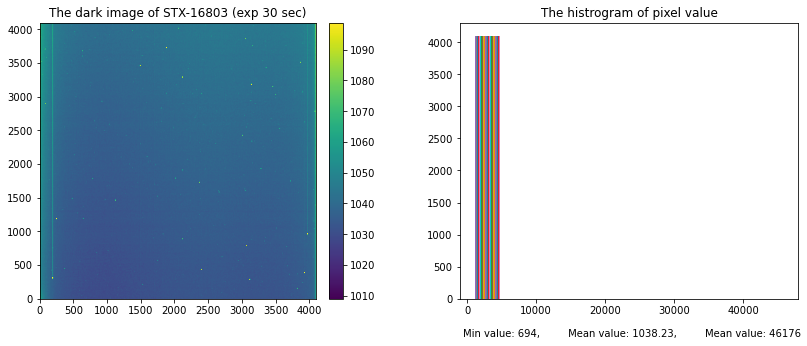

In [17]:
hdul = fits.open(dark_fits[5])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The dark image of STX-16803 (exp 30 sec)')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul[0].data.min()}, \
        Mean value: {hdul[0].data.mean():.02f}, \
        Mean value: {hdul[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')
plt.tight_layout(pad=5.0)

## Flat

In [18]:
flat_fits = summary.loc[summary["IMAGETYP"] == "FLAT"].copy()
flat_fits.reset_index(inplace=True)
flat_fits = flat_fits["file"]
print(type(flat_fits))
print(len(flat_fits))
print(flat_fits)

<class 'pandas.core.series.Series'>
18
0     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
1     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
2     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
3     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
4     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
5     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
6     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
7     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
8     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
9     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
10    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
11    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
12    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
13    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
14    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
15    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
16    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
17    R:\

In [19]:
if (MASTERDIR/'master_flat.fits').exists():
    print(f"{(MASTERDIR/'master_flat.fits')} is already exist...")
else:
    method = "median"
    flat = combine(flat_fits.tolist(),       # ccdproc does not accept numpy.ndarray, but only python list.
                        method = method,         # default is average so I specified median.
                        unit='adu')              # unit is required: it's ADU in our case.

    bias.data = np.array(bias.data, dtype=np.float32)

    print('type(flat.data)', type(flat.data))
    print('flat.data.shape', flat.data.shape)
    print('flat', flat)
    flat.write(f"{str(MASTERDIR/'master_flat.fits')}", overwrite =True)
    print(f"{(MASTERDIR/'master_flat.fits')} is created...")

INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]


type(flat.data) <class 'numpy.ndarray'>
flat.data.shape (4096, 4096)
flat [[23384.5 22777.  22709.  ... 22871.5 23150.5 23002. ]
 [23282.  22855.5 23045.5 ... 22760.5 23286.  22746.5]
 [23096.5 23030.  23088.  ... 22848.  23076.  22945.5]
 ...
 [21384.  20950.5 20899.  ... 22242.5 22315.5 22557. ]
 [21266.5 21213.  21141.  ... 22412.5 22362.  22672.5]
 [ 1575.   1593.5  1576.  ...  1570.5  1560.5  1525. ]] adu
R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\master_files_ys\master_flat.fits is created...


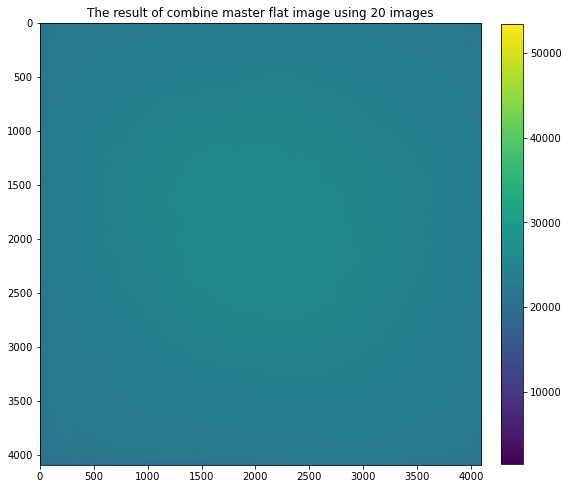

In [20]:
from astropy.io import fits
hdul_flat = fits.open(f"{str(MASTERDIR/'master_flat.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = axs.imshow(hdul_flat[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master flat image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

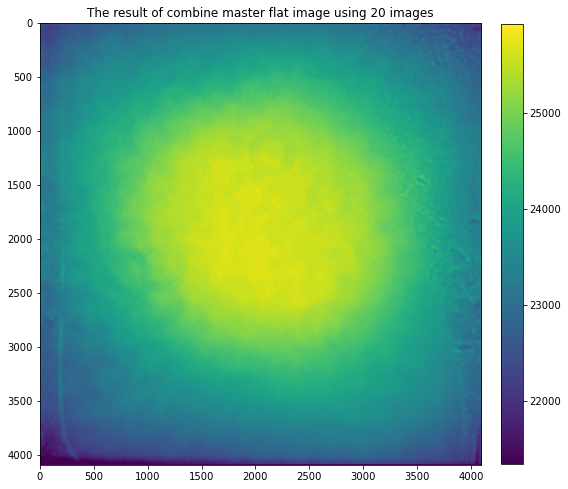

In [21]:
from astropy.io import fits
hdul_flat = fits.open(f"{str(MASTERDIR/'master_flat.fits')}")

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul_flat[0].data, 
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

axs.set_title('The result of combine master flat image using 20 images')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

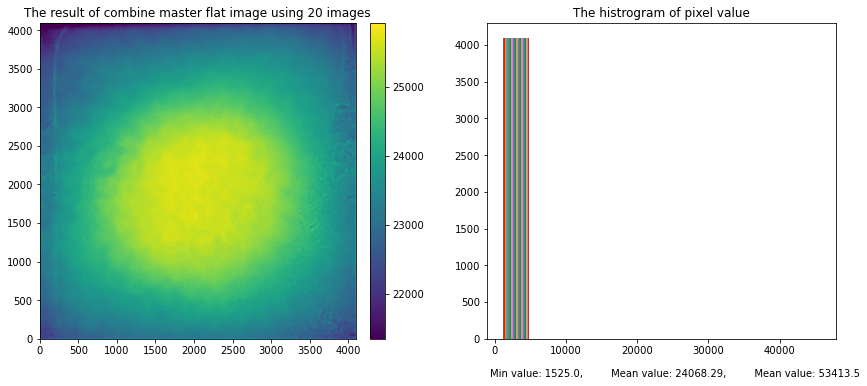

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul_flat[0].data)
im2 = axs[1].hist(hdul_dark0[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The result of combine master flat image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul_flat[0].data.min()}, \
        Mean value: {hdul_flat[0].data.mean():.02f}, \
        Mean value: {hdul_flat[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

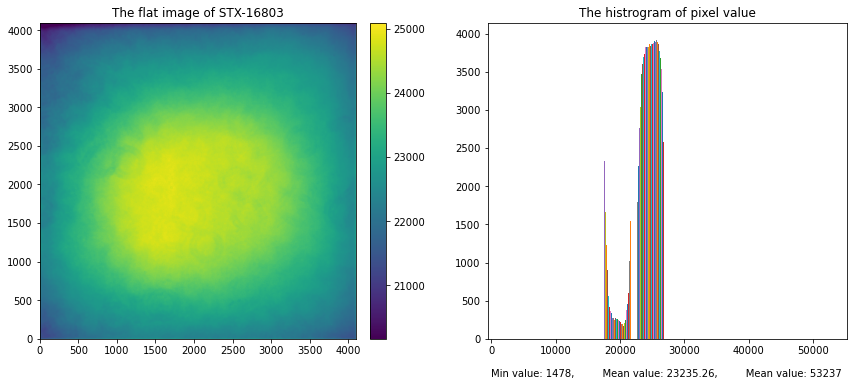

In [23]:
hdul = fits.open(flat_fits[3])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul[0].data.min()}, \
        Mean value: {hdul[0].data.mean():.02f}, \
        Mean value: {hdul[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

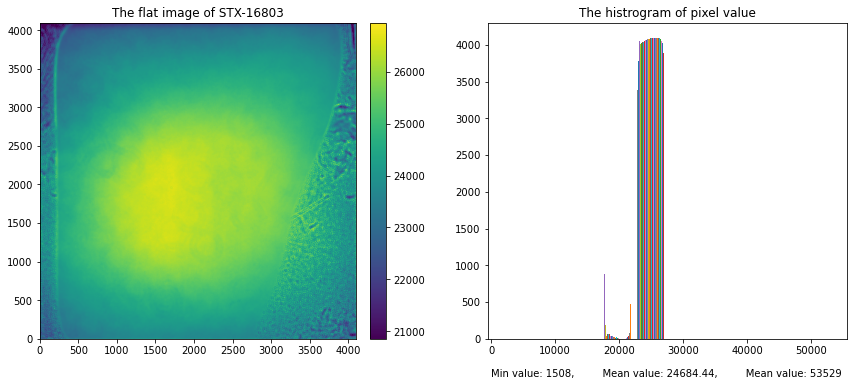

In [24]:
hdul = fits.open(flat_fits[10])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul[0].data.min()}, \
        Mean value: {hdul[0].data.mean():.02f}, \
        Mean value: {hdul[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

In [28]:
hdul[0].header["CCD-TEMP"]

-25.0

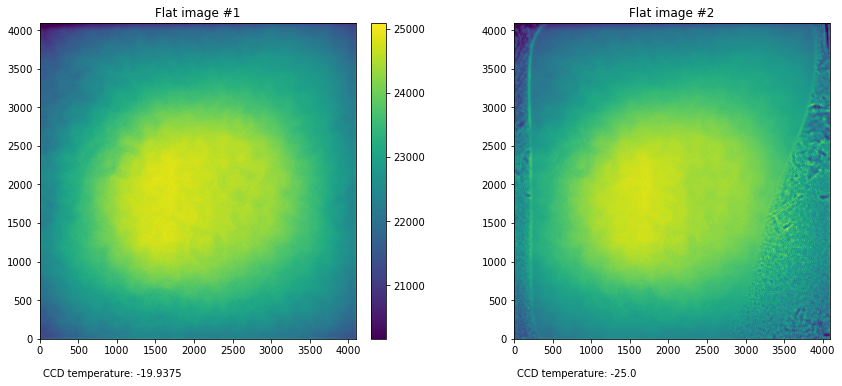

In [32]:
hdul1 = fits.open(flat_fits[3])
hdul2 = fits.open(flat_fits[10])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul1[0].data)
im2 = yvu.zimshow(axs[1], hdul2[0].data)

axs[0].set_title('Flat image #1')
axs[1].set_title('Flat image #2')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

axs[0].annotate(f"CCD temperature: {hdul1[0].header['CCD-TEMP']}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')
axs[1].annotate(f"CCD temperature: {hdul2[0].header['CCD-TEMP']}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

## Flat image

skyflat image

C:\Users\Kiehyun\AppData\Local\Temp/ipykernel_12880/1132229479.py:14: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(im1, fraction=0.0455, pad=0.04)


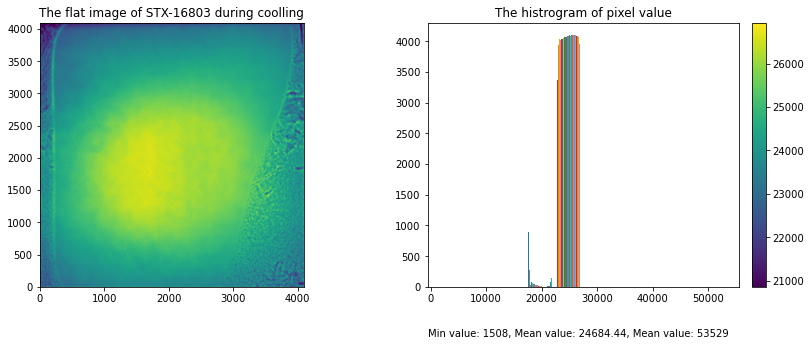

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803 during coolling')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)